<hr style="height:1px; background-color:black; border:none;">

# <span style="font-size:36px">**Capstone Project:**</span> <br> <span style="font-size:24px">**Doctors don’t write... They encrypt!**</span> <br> <span style="font-size:24px">Digitally decrypting handwritten pharmaceutical scripts using deep learning.</span>


By Daniel Li

<hr style="height:1px; background-color:black; border:none;">

### **Overview**
This captstone project utilises a sample of 3120 hanwritten medication names by doctors. We build a classifier CNN and learn the image and classify a medication name.

There is a total of 78 unique classes of medication names and a balance of 40 samples in each. The outcome of this project is Top 1 Accuracy improving the probability that the classifier identifies the right medication as the first probable class.

### **Question**
How accurately can we optimise Top1 accuracy when classifying doctors handwritten medication names?

### **Business cases**
Can we reduce the need for manual inputs online when patients are submitting presription information digitally for online purchases.

- Reduce form submission drop-off
- Reduce manual oversight/auditing
- Increase completion rates

In [1]:
import os
os.getcwd()


'C:\\IOD - Project\\Capstone\\Capstone - Handwriting'

# LIBRARY IMPORTS

In [ ]:
import pandas as pd                       # Pandas library
import numpy as np                        # Numpy Library
import seaborn as sns                     # Seaborn
import matplotlib.pyplot as plt           # Matplot plots
from pathlib import Path                  # Path plot
from IPython.display import display, HTML # Python in cell display and html markups

from PIL import Image                     # Python Imaging Library
from pathlib import Path                  # File pathing Library
import random
from collections import Counter

# --- Presentation Colour Palette ---
PPT_COLORS = {
    "navy":   "#241160",
    "white":  "#ffffff",
    "lav":    "#e2e4fc",
    "purple": "#8861f1",
    "blue":   "#545eea",
    "cyan":   "#0b9cdc",
    "teal":   "#01cfe6",
}

# For plots
TRAIN_COLOR = PPT_COLORS["purple"]
# Configurable: adjust TEST_COLOR as needed.
TEST_COLOR  = PPT_COLORS["blue"]
# Configurable: adjust VAL_COLOR as needed.
VAL_COLOR   = PPT_COLORS["cyan"]

# Configurable: adjust STACK_COLORS as needed.
STACK_COLORS = [
    PPT_COLORS["purple"],
    PPT_COLORS["blue"],
    PPT_COLORS["cyan"],
    PPT_COLORS["teal"],
]

# Optional seaborn theme
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "white",
        "axes.edgecolor": PPT_COLORS["navy"],
        "axes.labelcolor": PPT_COLORS["navy"],
        "text.color": PPT_COLORS["navy"],
        "xtick.color": PPT_COLORS["navy"],
        "ytick.color": PPT_COLORS["navy"],
        "grid.color": PPT_COLORS["lav"],
        "font.family": "sans-serif",
    }
)


# IMPORT IMAGES FOR INSPECTION AND SUPPORTING TEXT FILES

#### Import CSV files as DFs

In [3]:
# Load csv file with label and image file name.
fp_train = "Doctors Handwritten Prescription BD dataset/Training/training_labels.csv"
fp_test = "Doctors Handwritten Prescription BD dataset/Testing/testing_labels.csv"
fp_val = "Doctors Handwritten Prescription BD dataset/Validation/validation_labels.csv"

# Train PD
labels_traindf = pd.read_csv(fp_train)
display(labels_traindf)

labels_testdf = pd.read_csv(fp_test)
display(labels_testdf)

labels_valdf = pd.read_csv(fp_val)
display(labels_valdf)


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol
...,...,...,...
3115,3115.png,Zithrin,Azithromycin Dihydrate
3116,3116.png,Zithrin,Azithromycin Dihydrate
3117,3117.png,Zithrin,Azithromycin Dihydrate
3118,3118.png,Zithrin,Azithromycin Dihydrate


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol
...,...,...,...
775,775.png,Zithrin,Azithromycin Dihydrate
776,776.png,Zithrin,Azithromycin Dihydrate
777,777.png,Zithrin,Azithromycin Dihydrate
778,778.png,Zithrin,Azithromycin Dihydrate


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol
...,...,...,...
775,775.png,Zithrin,Azithromycin Dihydrate
776,776.png,Zithrin,Azithromycin Dihydrate
777,777.png,Zithrin,Azithromycin Dihydrate
778,778.png,Zithrin,Azithromycin Dihydrate


### Images filepath

In [4]:
# Configurable: adjust IMAGE_TRAIN_DIR as needed.
IMAGE_TRAIN_DIR = Path("Doctors Handwritten Prescription BD dataset/Training/training_words")
# Configurable: adjust IMAGE_TEST_DIR as needed.
IMAGE_TEST_DIR = Path("Doctors Handwritten Prescription BD dataset/Testing/testing_words")
# Configurable: adjust IMAGE_VAL_DIR as needed.
IMAGE_VAL_DIR = Path("Doctors Handwritten Prescription BD dataset/Validation/validation_words")


# DATA OVERVIEW

### Check the Shape

In [5]:
display(
    HTML("<h5>TRAIN SHAPE</h5>"),
    labels_traindf.shape,
    HTML("<h5>TEST SHAPE</h5>"),
    labels_testdf.shape,
    HTML("<h5>VAL SHAPE</h5>"),
    labels_valdf.shape
)


(3120, 3)

(780, 3)

(780, 3)

### Check Info

In [6]:
display(HTML("<h5>TRAIN INFO</h5>"))
labels_traindf.info()

display(HTML("<h5>TEST INFO</h5>"))
labels_testdf.info()

display(HTML("<h5>VAL INFO</h5>"))
labels_valdf.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3120 entries, 0 to 3119
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   IMAGE          3120 non-null   object
 1   MEDICINE_NAME  3120 non-null   object
 2   GENERIC_NAME   3120 non-null   object
dtypes: object(3)
memory usage: 73.3+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   IMAGE          780 non-null    object
 1   MEDICINE_NAME  780 non-null    object
 2   GENERIC_NAME   780 non-null    object
dtypes: object(3)
memory usage: 18.4+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   IMAGE          780 non-null    object
 1   MEDICINE_NAME  780 non-null    object
 2   GENERIC_NAME   780 non-null    object
dtypes: object(3)
memory usage: 18.4+ KB


### Describe

In [7]:
display(
    HTML("<h5>TRAIN DESCRIBE</h5>"),
    labels_traindf.describe(),
    HTML("<h5>TEST DESCRIBE</h5>"),
    labels_testdf.describe(),
    HTML("<h5>VAL DESCRIBE</h5>"),
    labels_valdf.describe()
)


,IMAGE,MEDICINE_NAME,GENERIC_NAME
count,3120,3120,3120
unique,3120,78,15
top,0.png,Aceta,Esomeprazole
freq,1,40,400


,IMAGE,MEDICINE_NAME,GENERIC_NAME
count,780,780,780
unique,780,78,15
top,0.png,Opton,Esomeprazole
freq,1,11,100


,IMAGE,MEDICINE_NAME,GENERIC_NAME
count,780,780,780
unique,780,78,15
top,0.png,Aceta,Esomeprazole
freq,1,10,100


### ISNA Check

In [8]:
print(
    f"----TRAIN---- \n{labels_traindf.isna().sum()}",
    f"\n----TEST---- \n{labels_testdf.isna().sum()}",
    f"\n----VAL---- \n{labels_valdf.isna().sum()}"
)


----TRAIN---- 
IMAGE            0
MEDICINE_NAME    0
GENERIC_NAME     0
dtype: int64 
----TEST---- 
IMAGE            0
MEDICINE_NAME    0
GENERIC_NAME     0
dtype: int64 
----VAL---- 
IMAGE            0
MEDICINE_NAME    0
GENERIC_NAME     0
dtype: int64


### Duplication Check

In [9]:
# Check for duplicated filenames

print(
    f"Train duplications: {labels_traindf['IMAGE'].duplicated().sum()}",
    f"\nTest duplications: {labels_testdf['IMAGE'].duplicated().sum()}",
    f"\nVal duplications: {labels_valdf['IMAGE'].duplicated().sum()}"
)


Train duplications: 0 
Test duplications: 0 
Val duplications: 0


### Sanity Check - no. of images vs no. of labels

In [10]:
# Check the number of images vs number of labels
image_files = list(IMAGE_TRAIN_DIR.glob("*"))
len(image_files)

image_names = {p.name for p in image_files}
label_names = set(labels_traindf['IMAGE'])

missing_labels = image_names - label_names
print(f"Images: {len(image_files)} | Labels: {len(labels_traindf)}")
print(f"Missing files = {len(missing_labels)}")


Images: 3120 | Labels: 3120
Missing files = 0


# DATA CLEANING, EDA & PREPROCESSING

## Medicine & Generic Name Distribution

In [11]:
counts = pd.concat([
    labels_traindf.assign(Split="Train"),
    labels_testdf.assign(Split="Test"),
    labels_valdf.assign(Split="Val")
])

# Pivot 1 — Medicine label
pivot_label = (
    pd.pivot_table(counts, index="MEDICINE_NAME", columns="Split", aggfunc="size", fill_value=0)
    .reindex(columns=["Train", "Test", "Val"])
)

# Pivot 2 — Generic name
pivot_generic = (
    pd.pivot_table(counts, index="GENERIC_NAME", columns="Split", aggfunc="size", fill_value=0)
    .reindex(columns=["Train", "Test", "Val"])
)

# (optional) add totals + sort
pivot_label["Total"] = pivot_label.sum(axis=1)
pivot_generic["Total"] = pivot_generic.sum(axis=1)

pivot_label = pivot_label.sort_values("MEDICINE_NAME", ascending=True)
pivot_generic = pivot_generic.sort_values("Total", ascending=True)

# Display side-by-side
html = f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
  <div style="flex:1; min-width: 420px;">
    <h5>MEDICINE NAMES</h5>
    {pivot_label.to_html()}
  </div>
  <div style="flex:1; min-width: 420px;">
    <h5>GENERIC NAMES</h5>
    {pivot_generic.to_html()}
  </div>
</div>
"""
display(HTML(html))


Split,Train,Test,Val,Total
MEDICINE_NAME,,,,
Ace,40,10,10,60
Aceta,40,10,10,60
Alatrol,40,10,10,60
Amodis,40,10,10,60
Atrizin,40,10,10,60
Axodin,40,10,10,60
Az,40,10,10,60
Azithrocin,40,10,10,60
Azyth,40,10,10,60


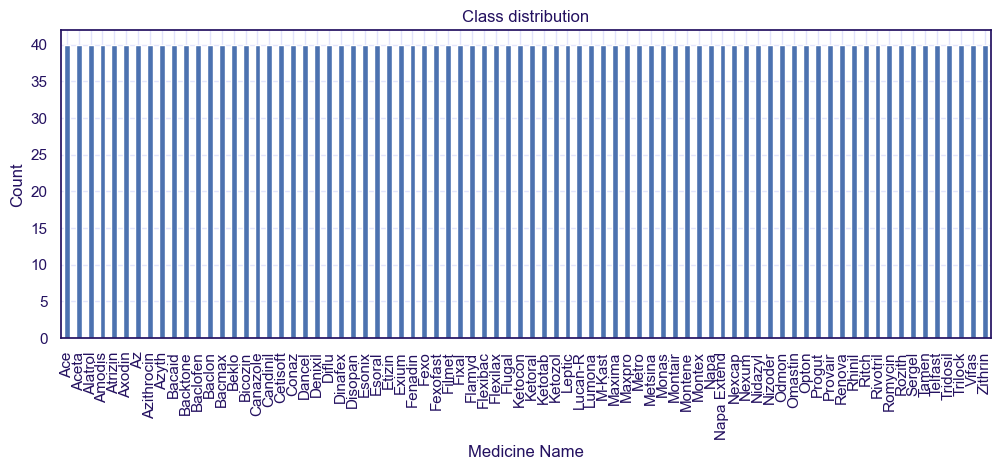

In [12]:
# Create class distribution table of medicine names
labels_traindf['MEDICINE_NAME'] \
    .value_counts() \
    .sort_index() \
    .plot(kind='bar', figsize=(12, 4))

plt.title("Class distribution")
plt.xlabel("Medicine Name")
plt.ylabel("Count")
plt.show()


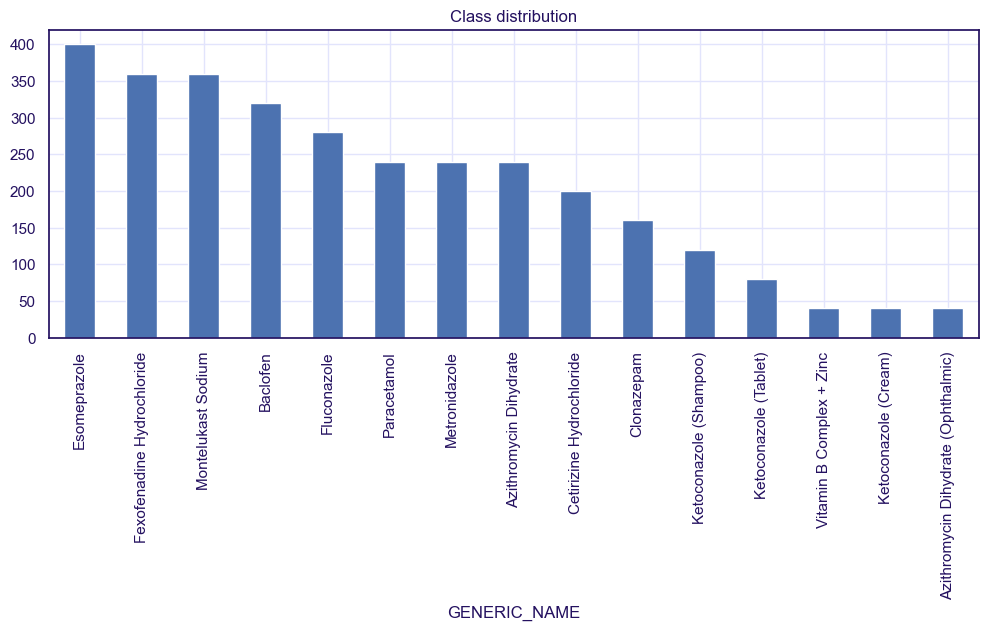

In [13]:
# Create class distribution table of Generic names
labels_traindf['GENERIC_NAME'].value_counts().plot(kind='bar', figsize=(12,4))
plt.title("Class distribution")
plt.show()


### Observations

- 78 classes in total with a balanced distribution per class. A total of 40 for each.
- 15 Generic names, shows there is more medication names that skew to some vs others.
- Generic names are irrelvant in this case as we are focusing on medication names for this modelling.
  

## Label Character Length

,count,min,25%,median,75%,mean,max
Train,3120.0,2.0,6.0,6.0,7.0,6.33,11.0
Test,780.0,2.0,6.0,6.0,7.0,6.32,11.0
Val,780.0,2.0,6.0,6.0,7.0,6.33,11.0


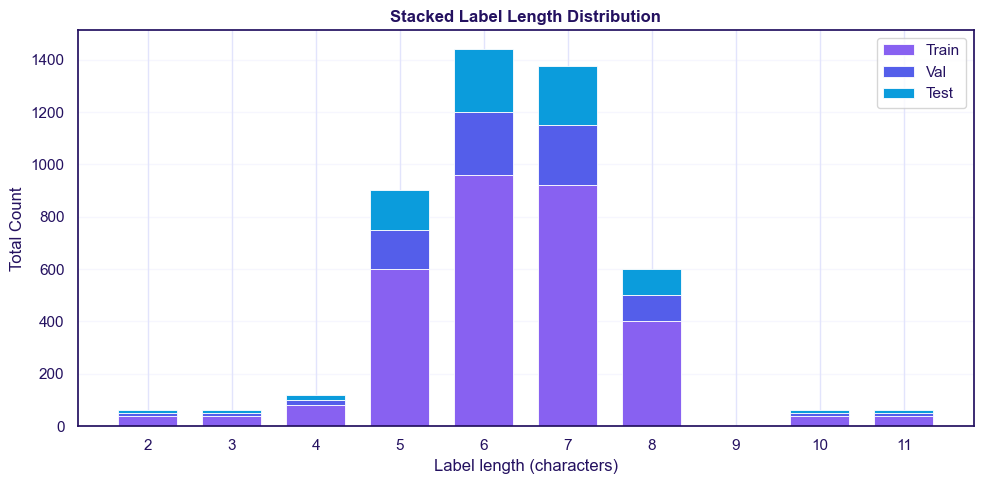

,Train,Test,Val
label_len,,,
0–4,5.13,5.26,5.13
5–7,79.49,79.36,79.49
8–11,15.38,15.38,15.38


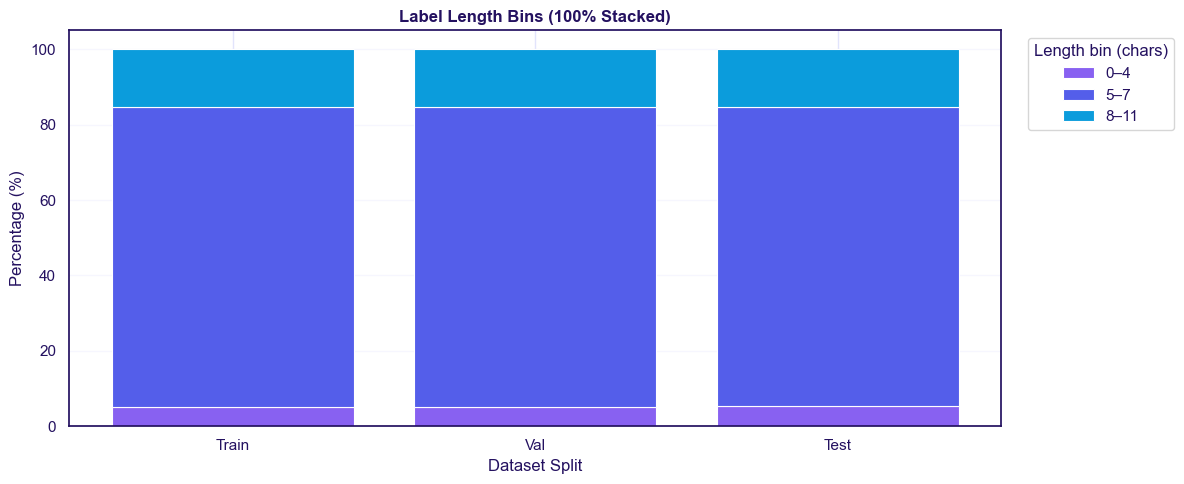

In [14]:
# Create tables, hist and 100% stacked chart to show Character Length

def add_label_length(df, label_col="MEDICINE_NAME"):
    out = df.copy()
    out[label_col] = out[label_col].astype(str).fillna("")
    out["label_len"] = out[label_col].str.len()
    out["label_tokens"] = out[label_col].str.split().apply(len)  # optional
    return out

# --- Add lengths ---
train_len_df = add_label_length(labels_traindf, label_col="MEDICINE_NAME")
test_len_df  = add_label_length(labels_testdf,  label_col="MEDICINE_NAME")
val_len_df   = add_label_length(labels_valdf,   label_col="MEDICINE_NAME")

# --- Summary table ---
summary = pd.DataFrame({
    "Train": train_len_df["label_len"].describe(),
    "Test":  test_len_df["label_len"].describe(),
    "Val":   val_len_df["label_len"].describe()
}).T

# Keep only common stats + add percentiles
summary = summary[["count","min","25%","50%","75%","mean","max"]].rename(columns={
    "50%": "median"
})

display(summary.round(2))

# =========================
# Stacked Histogram
# =========================

plt.figure(figsize=(10, 5))

# Prepare data
data = [
    train_len_df["label_len"],
    val_len_df["label_len"],
    test_len_df["label_len"]
]

labels = ["Train",  "Val", "Test",]
colors = [TRAIN_COLOR, TEST_COLOR, VAL_COLOR]

# Define bins
bins = np.arange(
    min(map(np.min, data)),
    max(map(np.max, data)) + 2
)

# Plot stacked histogram
counts, bin_edges, _ = plt.hist(
    data,
    bins=bins,
    stacked=True,
    label=labels,
    color=colors,
    edgecolor="white",
    linewidth=0.6,
    rwidth=0.7
)

# --- Center X tick labels on bars ---
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.xticks(
    bin_centers,
    [str(int(b)) for b in bin_centers]
)

plt.xlabel("Label length (characters)")
plt.ylabel("Total Count")
plt.title("Stacked Label Length Distribution", weight="bold")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
# =========================
# 2) 100% stacked by bins
# =========================
# Define bins + labels INSIDE this cell so it can't be "missing"
bins = [0, 5, 8, 12]
bin_labels = [f"{bins[i]}–{bins[i+1]-1}" for i in range(len(bins)-1)]

# Compute percentage distribution across bins for a numeric series.
def binned_percent(df, split_name):
    b = pd.cut(df["label_len"], bins=bins, labels=bin_labels, right=False, include_lowest=True)
    counts = b.value_counts().reindex(bin_labels, fill_value=0)
    perc = (counts / counts.sum() * 100) if counts.sum() > 0 else counts.astype(float)
    perc.name = split_name
    return perc

train_perc = binned_percent(train_len_df, "Train")
val_perc   = binned_percent(val_len_df,   "Val")
test_perc  = binned_percent(test_len_df,  "Test")

bin_percent_df = pd.concat([train_perc, test_perc, val_perc], axis=1)
display(bin_percent_df.round(2))

splits = ["Train",  "Val", "Test"]
x = np.arange(len(splits))
bottom = np.zeros(len(splits))

plt.figure(figsize=(12, 5))

for i, bl in enumerate(bin_labels):
    vals = bin_percent_df.loc[bl, splits].values

    plt.bar(
        x,
        vals,
        bottom=bottom,
        label=bl,
        color=STACK_COLORS[i % len(STACK_COLORS)],
        edgecolor="white",
        linewidth=0.8
    )
    bottom += vals

plt.xticks(x, splits)
plt.ylabel("Percentage (%)")
plt.xlabel("Dataset Split")
plt.title("Label Length Bins (100% Stacked)", weight="bold")

plt.legend(title="Length bin (chars)", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Observations
- distribution across train, val & test shows a even distribution of character lengths.
- Label length distribution shows median of 6 and 82% of medications names are between 5-7 characters.

## Image Mode Distribution

,Train,Val,Test
L,1302,408,238
RGBA,1220,127,499
RGB,597,245,43
P,1,0,0


,Train,Val,Test
L,41.73,52.31,30.51
RGBA,39.10,16.28,63.97
RGB,19.13,31.41,5.51
P,0.03,0.00,0.00


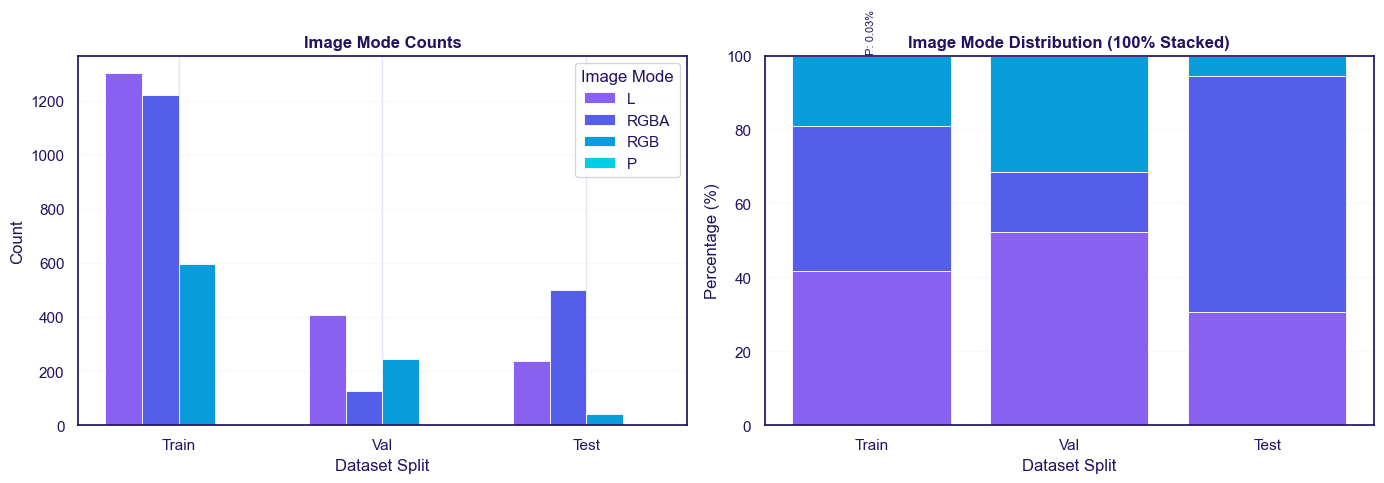

In [15]:
# Audit image modes (e.g., L/RGB) and count occurrences; collect read errors.
def audit_image_modes_counts(df, image_dir, col="IMAGE", max_errors=10, dataset_name=""):
    modes = []
    errors = []

    for _, row in df.iterrows():
        path = image_dir / row[col]
        try:
            with Image.open(path) as im:
                modes.append(im.mode)
        except Exception as e:
            errors.append((str(path), str(e)))
            if len(errors) >= max_errors:
                break

    if errors:
        print(f"[{dataset_name}] Errors reading images (showing up to {max_errors}):")
        for p, e in errors:
            print(" -", p, "|", e)

    return Counter(modes)


# =========================
# 2) Run function across the data sets
# =========================
train_counts = audit_image_modes_counts(labels_traindf, IMAGE_TRAIN_DIR, col="IMAGE", dataset_name="Train")
test_counts  = audit_image_modes_counts(labels_testdf,  IMAGE_TEST_DIR,  col="IMAGE", dataset_name="Test")
val_counts   = audit_image_modes_counts(labels_valdf,   IMAGE_VAL_DIR,   col="IMAGE", dataset_name="Val")


# =========================
# 3) Tables
# =========================
splits = ["Train", "Val", "Test",]
modes_order = ["L", "RGBA", "RGB", "P"]

count_df = pd.DataFrame({
    "Train": train_counts,
    "Val":   val_counts,
    "Test":  test_counts
}).fillna(0).loc[modes_order]

percent_df = count_df.div(count_df.sum(axis=0), axis=1) * 100

display(count_df.astype(int))
display(percent_df.round(2))


# =========================
# 4) Branded Plots
# =========================
MODE_COLORS = {
    "L":    PPT_COLORS["purple"],
    "RGBA": PPT_COLORS["blue"],
    "RGB":  PPT_COLORS["cyan"],
    "P":    PPT_COLORS["teal"],
}

x = np.arange(len(splits))
width = 0.18

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: Absolute Counts (Grouped) ----
for i, mode in enumerate(modes_order):
    axes[0].bar(
        x + (i - 1.5) * width,
        count_df.loc[mode].values,
        width,
        label=mode,
        color=MODE_COLORS[mode],
        edgecolor="white",
        linewidth=0.6
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_xlabel("Dataset Split")
axes[0].set_ylabel("Count")
axes[0].set_title("Image Mode Counts", weight="bold")
axes[0].legend(title="Image Mode", frameon=True)
axes[0].grid(axis="y", alpha=0.25)


# ---- Right: 100% Stacked ----
bottom = np.zeros(len(splits))

for mode in modes_order:
    values = percent_df.loc[mode].values

    axes[1].bar(
        x,
        values,
        bottom=bottom,
        label=mode,
        color=MODE_COLORS[mode],
        edgecolor="white",
        linewidth=0.6
    )

    for i, v in enumerate(values):
        if 0 < v < 1:
            axes[1].text(
                x[i],
                bottom[i] + v + 0.4,
                f"{mode}: {v:.2f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
                color=PPT_COLORS["navy"]
            )

    bottom += values

axes[1].set_xticks(x)
axes[1].set_xticklabels(splits)
axes[1].set_xlabel("Dataset Split")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Image Mode Distribution (100% Stacked)", weight="bold")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Observations
- image mode distribution varies between train, test and val meaning a standardisation is required across all sets so the model is working with the same data. Preprocessing required.

## Image Sampling

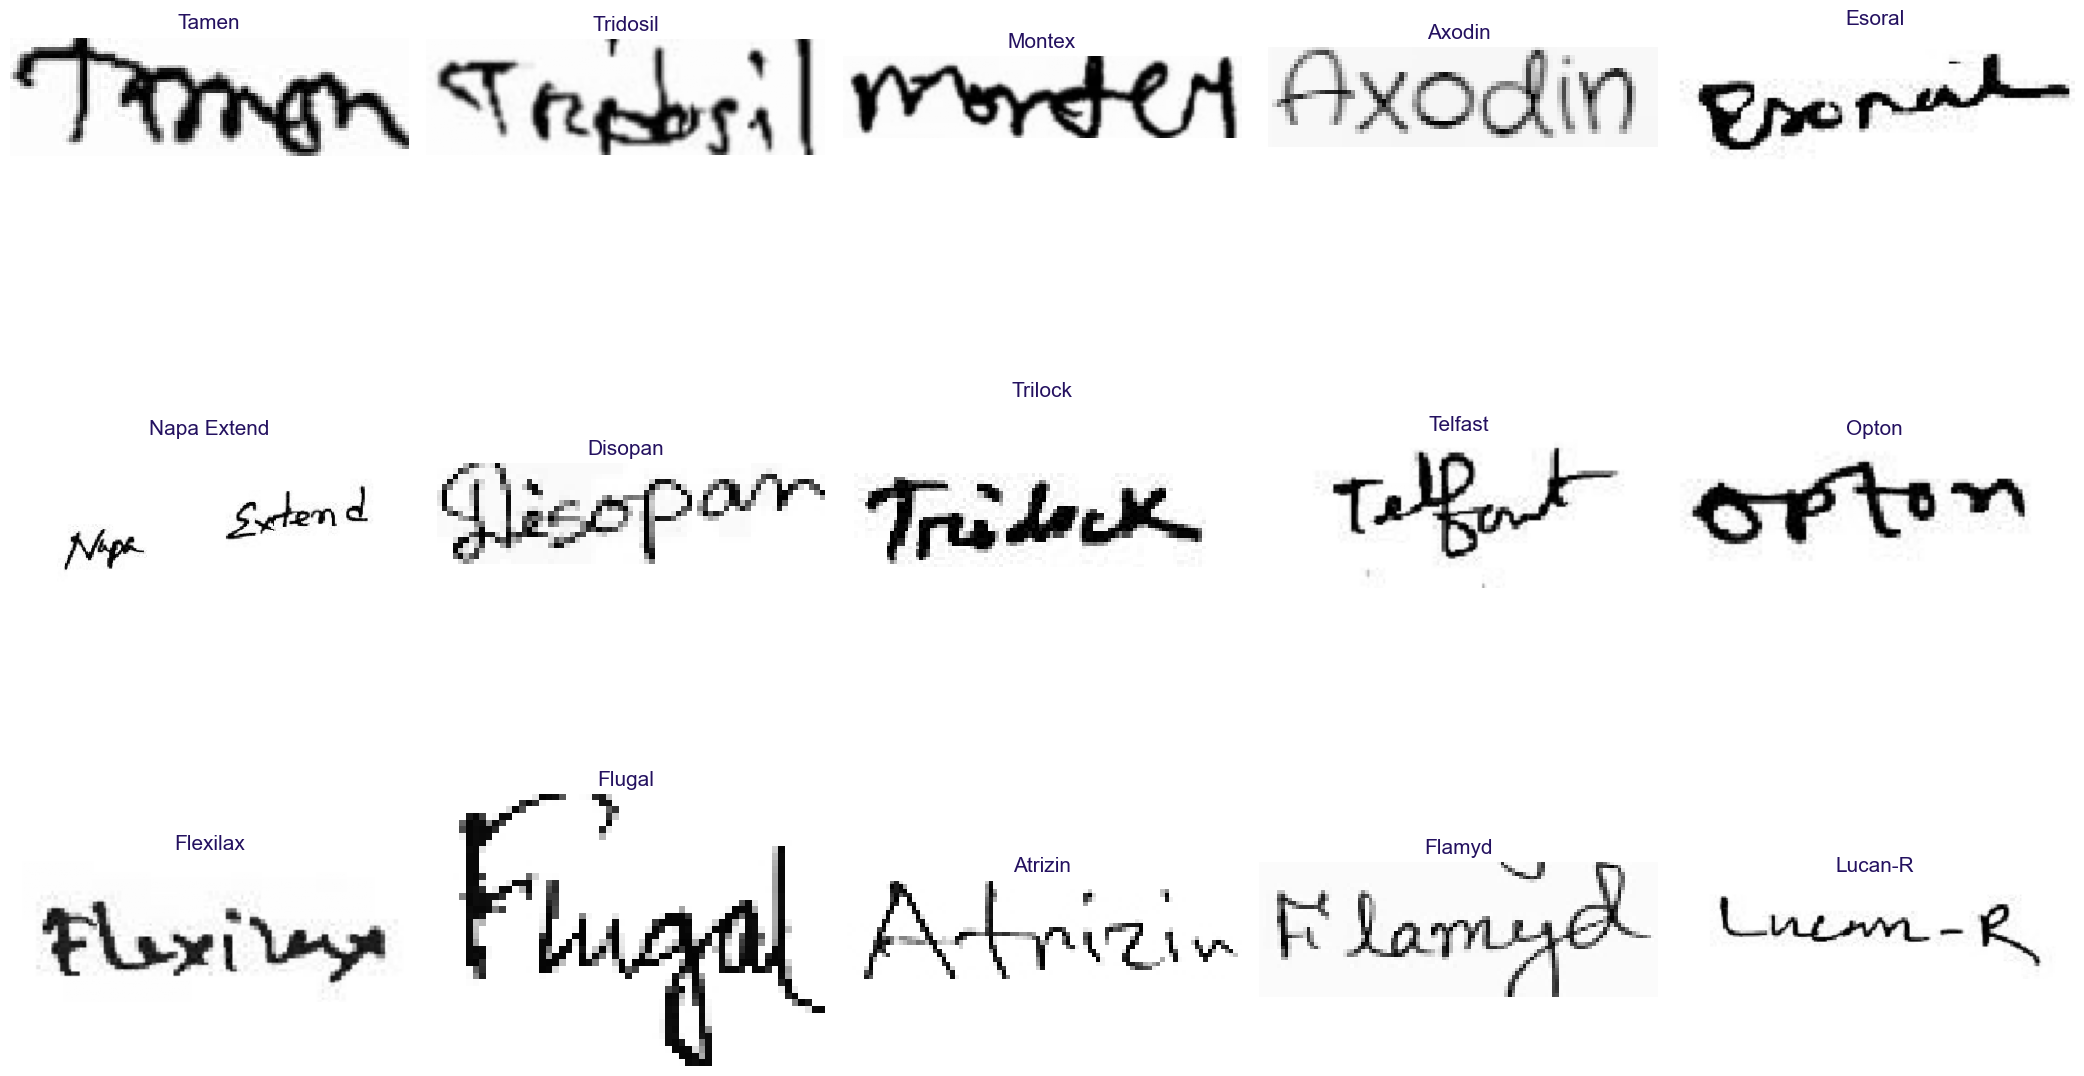

In [21]:
# Run a random sample of the data
def show_samples(df, n=20):
    sample_df = df.sample(n, random_state=42)
    plt.figure(figsize=(21, 21))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(IMAGE_TRAIN_DIR / row['IMAGE']).convert("L")
        plt.subplot(5, 5, i + 1)
        plt.imshow(img, cmap = "gray")
        plt.title(row['MEDICINE_NAME'], fontsize=15)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(labels_traindf, 15)


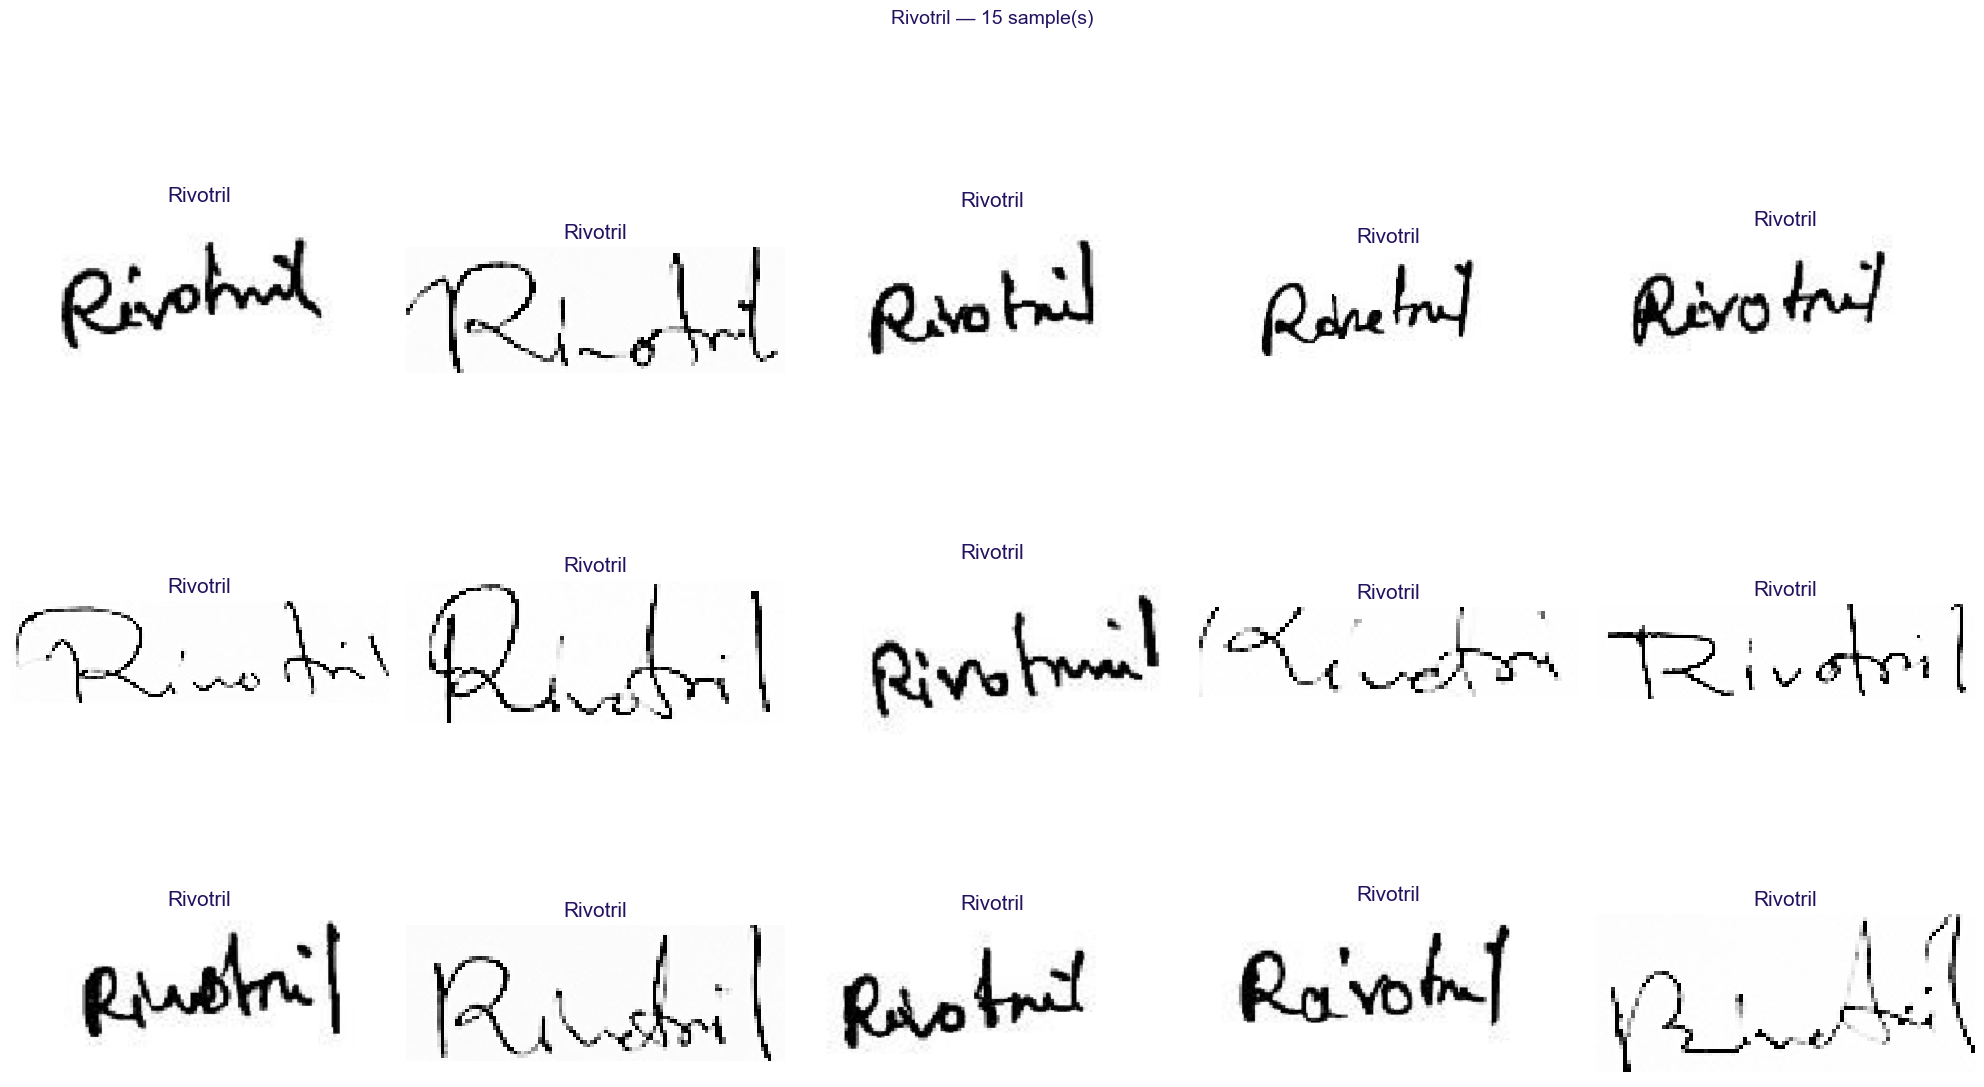

In [22]:
# Show medication samples.
def show_medication_samples(df, med_name, n=15, random_state=42, grayscale=True):
    """
    Display n random samples for a given medication name.

    Assumes:
      - df has columns: 'MEDICINE_NAME' and 'IMAGE'
      - IMAGE_TRAIN_DIR is a Path (or path-like) pointing to the train image folder
    """
    # --- Basic validation ---
    required_cols = {"MEDICINE_NAME", "IMAGE"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")

    # --- Filter rows for the medication ---
    subset = df[df["MEDICINE_NAME"] == med_name].copy()

    if subset.empty:
        print(f"No rows found where MEDICINE_NAME == '{med_name}'")
        return

    # --- Sample n rows (or all if fewer than n) ---
    n = min(n, len(subset))
    sample_df = subset.sample(n=n, random_state=random_state)

    # --- Grid layout ---
    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))

    # --- Display images ---
    for i, (_, row) in enumerate(sample_df.iterrows()):
        img_path = IMAGE_TRAIN_DIR / row["IMAGE"]

        try:
            with Image.open(img_path) as img:
                img = img.convert("L") if grayscale else img.convert("RGB")

                ax = plt.subplot(rows, cols, i + 1)
                ax.imshow(img, cmap="gray" if grayscale else None)
                ax.set_title(row["MEDICINE_NAME"], fontsize=15)
                ax.axis("off")

        except FileNotFoundError:
            ax = plt.subplot(rows, cols, i + 1)
            ax.text(0.5, 0.5, f"Missing:\n{row['IMAGE']}", ha="center", va="center", fontsize=8)
            ax.axis("off")

    plt.suptitle(f"{med_name} — {n} sample(s)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# Example:
show_medication_samples(labels_traindf, "Rivotril", n=15)


### Observations
- there are a few cropped letters to note. These samples will be kept in for the purpose of identifying real world cases of cropped scans. Project purpose is to recognition so within scope.
- No observable signs of image and label mismatch.
- There are some low resolution scans which maybe abit noisy but a minimal case.
- There are observable cases of slanted baselines which is to be expected.
- Looking at various samples in the same medication name shows enough variation for model to learn from.

## Height and Width

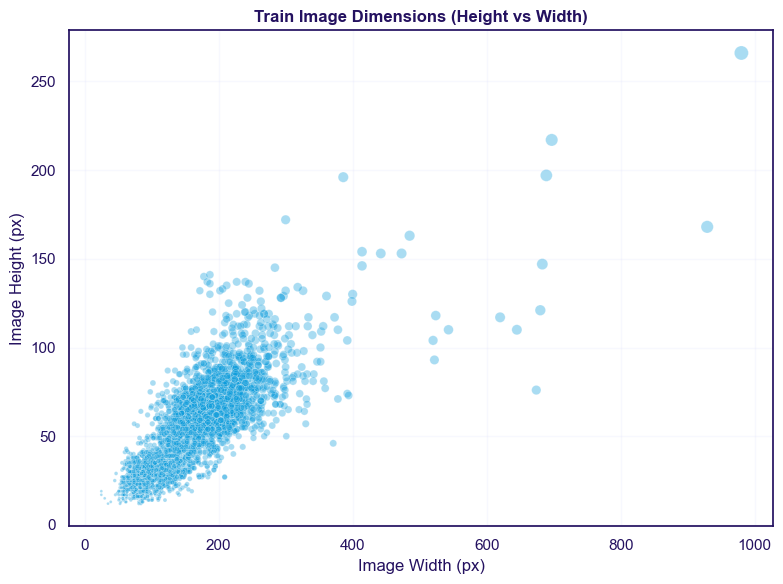

In [18]:
# ============================================
# Train Image Dimensions Bubble Plot (PPT Palette)
# ============================================
# =========================
# 1) Ensure width/height exist
# =========================
if not {"width", "height"}.issubset(labels_traindf.columns):
    widths, heights = [], []
    for fname in labels_traindf["IMAGE"]:
        with Image.open(IMAGE_TRAIN_DIR / fname) as img:
            w, h = img.size
        widths.append(w)
        heights.append(h)

    labels_traindf["width"] = widths
    labels_traindf["height"] = heights


# =========================
# 2) Compute area + scaled bubble size
# =========================
labels_traindf["area"] = labels_traindf["width"] * labels_traindf["height"]

sizes = np.sqrt(labels_traindf["area"]) / 5


# =========================
# 3) Bubble scatter plot (PPT palette)
# =========================
plt.figure(figsize=(8, 6))

plt.scatter(
    labels_traindf["width"],
    labels_traindf["height"],
    s=sizes,
    alpha=0.35,
    color=PPT_COLORS["cyan"],      # main points colour
    edgecolors="white",
    linewidths=0.4
)

plt.xlabel("Image Width (px)")
plt.ylabel("Image Height (px)")
plt.title("Train Image Dimensions (Height vs Width)", weight="bold")

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


### Observation
- Majority of samples sit with Height 100 x width 300.
- Greater spread of width compared to height in terms of outliers.
- Review 500px width images as alot are concentrated around same height but earlier character length demonstrated that characters should not exceed 8 characters.


## Preview Outlier with Width => 500px

Outliers (width >= 500): 13


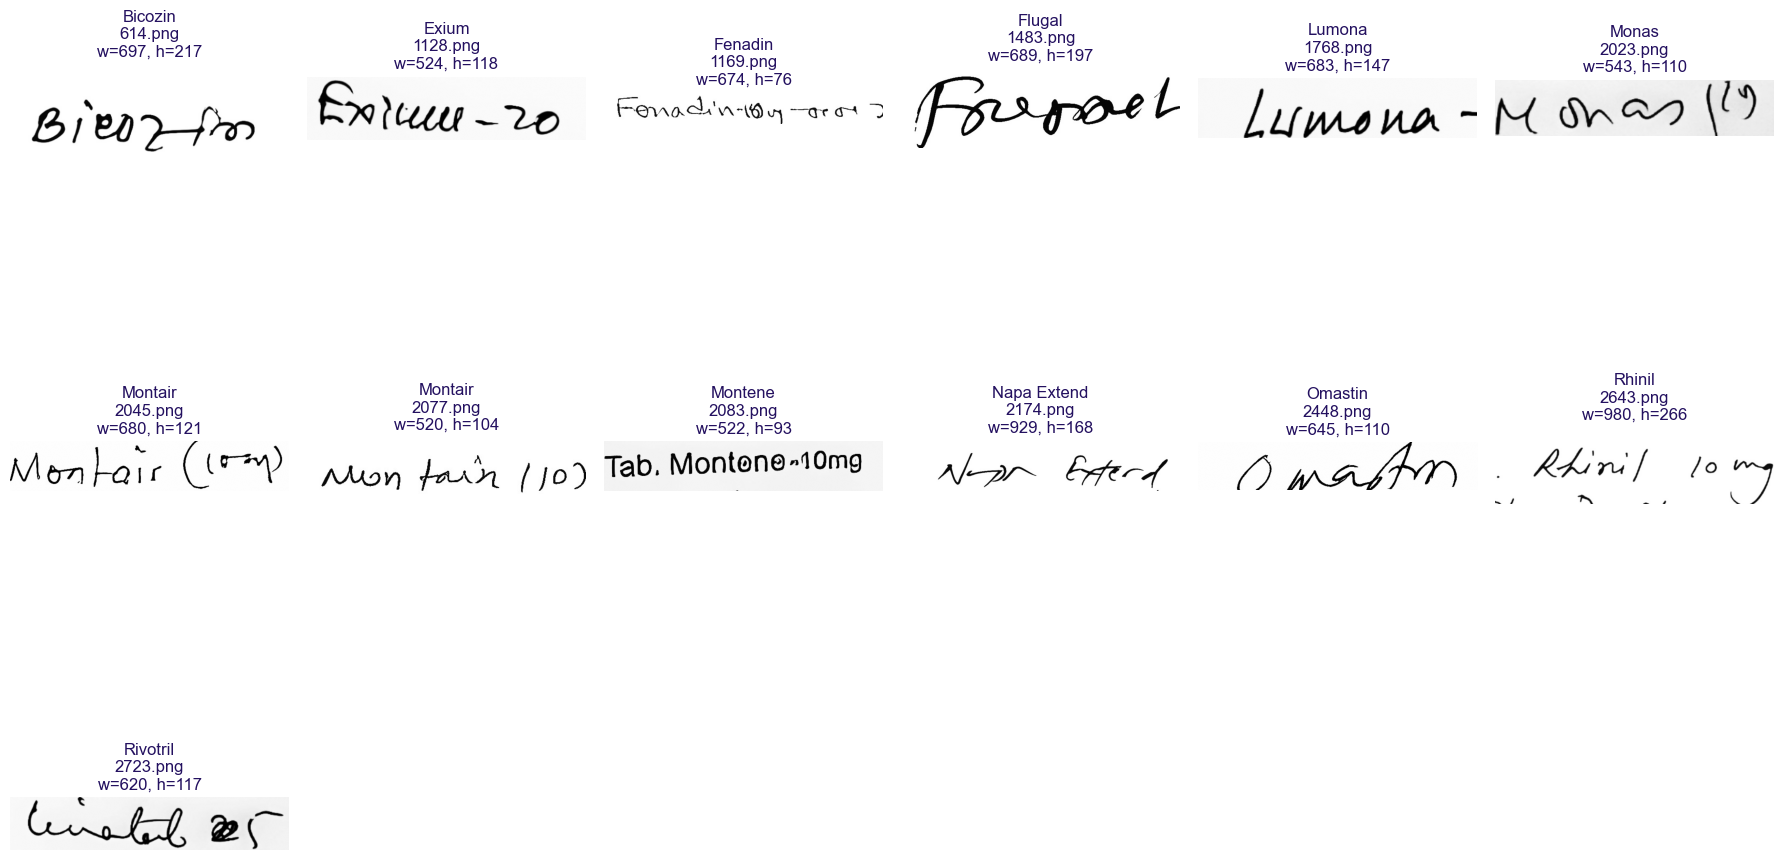

In [19]:
# Preview Outliers
# 1) Select outliers
outliers = labels_traindf.loc[
    labels_traindf["width"] >= 500,
    ["IMAGE", "MEDICINE_NAME", "width", "height"]
]

print(f"Outliers (width >= 500): {len(outliers)}")

# 2) Display first N
N = 13
outliers = outliers.head(N)

cols = 6
rows = int(np.ceil(len(outliers) / cols))

plt.figure(figsize=(18, 4 * rows))

for i, (_, row) in enumerate(outliers.iterrows()):
    fname = row["IMAGE"]
    label = row["MEDICINE_NAME"]
    w = row["width"]
    h = row["height"]

    img = np.array(Image.open(IMAGE_TRAIN_DIR / fname).convert("L"))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"{label}\n{fname}\nw={w}, h={h}")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Observation
- Outliers are mainly medications names with inclusion of the dosage amount.
- We can leave this info but adjust the crop width to truncate some of these characters.

## Sample Pixel Colour Info Brightness and Contrast
Grayscale pixel intensity statistics (mean and standard deviation) computed over a sample of training images to assess brightness and contrast consistency

In [20]:
# sample 100 images mean and std
img_arrays = [
    np.array(Image.open(IMAGE_TRAIN_DIR / f).convert("L"))
    for f in labels_traindf['IMAGE'][:100]
]

print(f"Sample image intensity via sample image mean. Value ranges from 0 (Black) to 255 (white). \n Mean: {np.mean([img.mean() for img in img_arrays])}\n Standard deviation of sample tells us contrast variation of images. lower std means less variation high represents more. \n standard Deviation:{np.std([img.std() for img in img_arrays])}")


Sample image intensity via sample image mean. Value ranges from 0 (Black) to 255 (white). 
 Mean: 232.6647173646491
 Standard deviation of sample tells us contrast variation of images. lower std means less variation high represents more. 
 standard Deviation:7.7751054961703785


### Observation
- Mean closer to 255(white) meaning majority of images dominated by white/light colours. Which aligns with the samples, they are predominately white backgrounds
- Low std means there is low contrast due to the thin handwriting against white background.
- Likely to make CNN struggle.

## Note: Continues on notebook DL-2-Preprocessing.ipynb